In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import fill 

### Завдання 1
Потрібно проаналізувати дані транзакцій інтернет-магазину та візуалізувати розподіл сум замовлень. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Завантажте дані з CSV у таблицю.

* Виведіть перші рядки та інформацію про стовпці.

* Визначте кількість пропусків за кожним стовпчиком.

* Побудуйте зведення за "amount": кількість, середнє, медіана, мінімум, максимум, квартилі та перцентилі.

* Побудуйте гістограму "amount" і коробчату діаграму.

* Видаліть пропуски в "amount" і повторіть розрахунок зведення.

* Виведіть усі результати та графіки.

In [2]:
sales = pd.read_csv("./sales02_4.csv")
sales



,ID,Товар,Категорія,Ціна,Кількість,Продано
0,1,Ноутбук Pro,Електроніка,45000,5.0,3.0
1,2,Мишка бездротова,Аксесуари,1200,50.0,22.0
2,3,Клавіатура RGB,NaN,2500,20.0,14.0
3,4,"Монітор 27""",Периферія,12000,10.0,10.0
4,5,Смартфон X,Гаджети,28000,15.0,8.0
5,6,Навушники ANC,Аудіо,5500,30.0,21.0
6,7,Принтер лазерний,Офісна техніка,8000,4.0,1.0
7,8,Зовнішній HDD,Накопичувачі,3200,25.0,NaN
8,9,Веб-камера 4K,Периферія,4100,12.0,11.0
9,10,Графічний планшет,Гаджети,15000,7.0,NaN


In [3]:
empties = sales.isnull().sum()
print ("кількість пропусків за кожним стовпчиком", empties, sep='\n')


кількість пропусків за кожним стовпчиком
ID           0
Товар        0
Категорія    1
Ціна         0
Кількість    1
Продано      2
dtype: int64


In [4]:
def stat(data):
    print("%s \n%d \n%d \n%d\n%d \n%s \n%s \n" % (
        data["Продано"].sum(),
        data["Продано"].mean(),
        data["Продано"].median(),
        data["Продано"].min(),        
        data["Продано"].max(),        
        data["Продано"].quantile([0.25, 0.5, 0.75]),        
        data["Продано"].quantile(0.90),        
    ))
stat(sales)


94.0 
10 
10 
1
22 
0.25     4.0
0.50    10.0
0.75    14.0
Name: Продано, dtype: float64 
21.2 



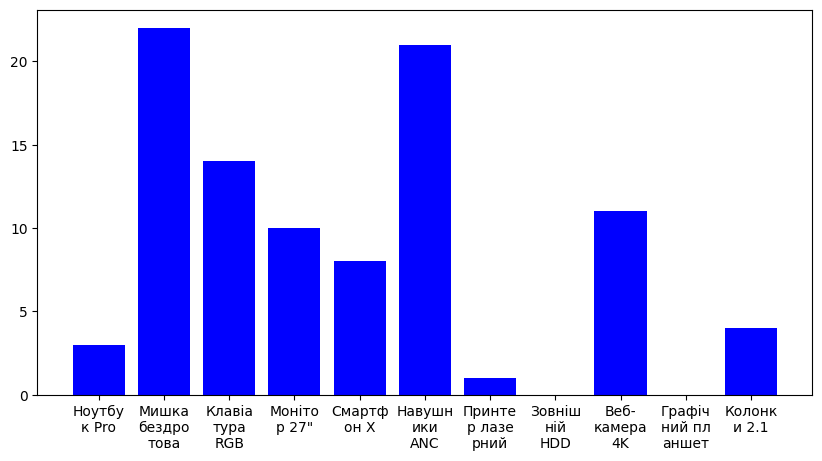

In [5]:
fig, ax = plt.subplots(figsize=(10,5))     
ax.bar([fill(name, width = 6) for name in  sales["Товар"]], sales["Продано"], color="blue")
plt.show()

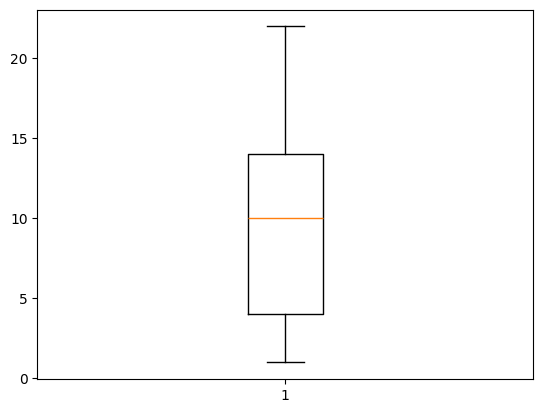

In [6]:
fig, ax = plt.subplots()     
ax.boxplot( sales["Продано"].dropna())
plt.show()

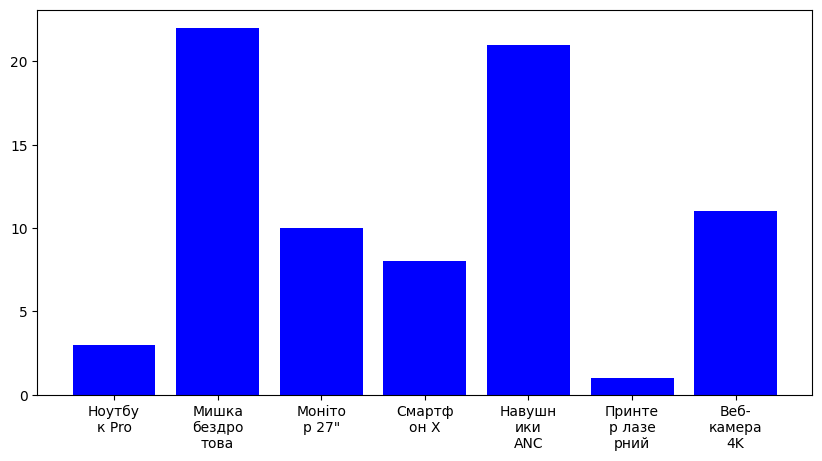

In [7]:
emptie = sales.dropna()
fig, ax = plt.subplots(figsize=(10,5))     
ax.bar([fill(name, width = 6) for name in  emptie['Товар']], emptie["Продано"], color="blue")
plt.show()

### Завдання 2
Потрібно змоделювати вибірку розмірів замовлень із додаванням викидів і провести базовий статистичний аналіз. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
* Створіть одновимірний масив додатних чисел і додайте кілька аномально великих значень.
* Перетворіть масив на таблицю з одним стовпчиком.
* Розрахуйте середнє, медіану, стандартне відхилення, IQR і MAD, коефіцієнти асиметрії та ексцесу.
* Побудуйте гістограму розподілу та коробчату діаграму.
* Визначте частку спостережень, що виходять за "вуса" коробчастої діаграми.
* Виведіть числові результати та графіки.



In [9]:
data = pd.DataFrame({"Продано": [*sales ['Продано'].dropna(),42]})
data 

,Продано
0,3.0
1,22.0
2,14.0
3,10.0
4,8.0
5,21.0
6,1.0
7,11.0
8,4.0
9,42.0


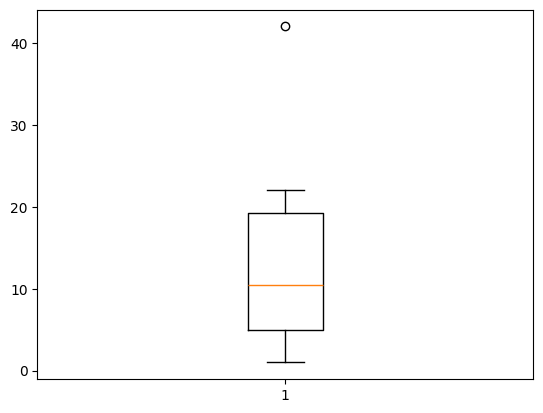

In [41]:
fig, ax = plt.subplots( )
plt.boxplot( data )
plt.show()

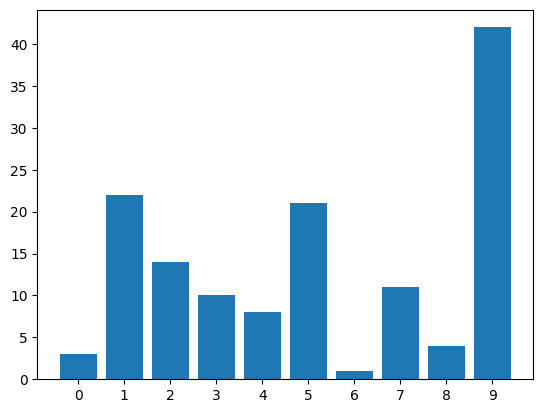

In [21]:

fig, ax = plt.subplots( )
ax.bar([str(i) for i in range(len(data))], data['Продано'])
plt.show()

In [39]:
Q1 = data['Продано'].quantile(0.25)
Q3 = data['Продано'].quantile(0.75)
IQR = Q3 - Q1
avg = data ['Продано'].mean()
mad = (data['Продано'] - avg).abs().mean()
print((
    "average number of products per sale: %.1f \n" +  
    "Median sales: %.1f \n" +
    "standard deviation of sales volume: %.1f \n"+
    "average absolute output sales volume: %.1f \n"+
    "interquartile range: %.1f \n"+
    ": %.1f \n"+
    ": %.1f \n"
) % (
    avg,
    data ['Продано'].median(),
    data ['Продано'].std(),
    mad,
    IQR,
    data ['Продано'].skew(),
    data ['Продано'].kurtosis(),
))



average number of products per sale: 13.6 
Median sales: 10.5 
standard deviation of sales volume: 12.2 
average absolute output sales volume: 8.9 
interquartile range: 14.2 
: 1.5 
: 2.5 



In [46]:
outliers = data[ (data['Продано'] > Q3 + 1.5 * IQR )| (data['Продано']< Q1 - 1.5 * IQR)]
len(outliers.index)

1